<a href="https://colab.research.google.com/github/abhaycs24/ShadowFox_PythonDeveloper_Internship/blob/main/Task_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. GENERATING FINANCIAL & SALES DATASET
Dataset successfully loaded! First 5 records:
  Transaction_ID       Date  Fiscal_Year  Gross_Sales  Net_Sales      COGS  \
0       TXN-1000 2023-01-01  FY2022-2023     12490.80   11830.78   6600.22   
1       TXN-1001 2023-01-02  FY2022-2023     24014.29   23013.30  10009.83   
2       TXN-1002 2023-01-03  FY2022-2023     19639.88   18790.80   8490.83   
3       TXN-1003 2023-01-04  FY2022-2023     16973.17   15989.22   9839.53   
4       TXN-1004 2023-01-05  FY2022-2023      8120.37    7697.07   4233.04   

   Freight_Costs  Profit_Loss  
0         334.06      4896.50  
1        1373.32     11630.16  
2         856.83      9443.14  
3        1274.39      4875.29  
4         616.06      2847.97  


2. DATASET EXPLORATION & CLEANING SUMMARY
Dataset Shape: (200, 8)

Missing Values Check:
 Transaction_ID    0
Date              0
Fiscal_Year       0
Gross_Sales       0
Net_Sales         0
COGS              0
Freight_Costs     0
Profit_Loss       0
d

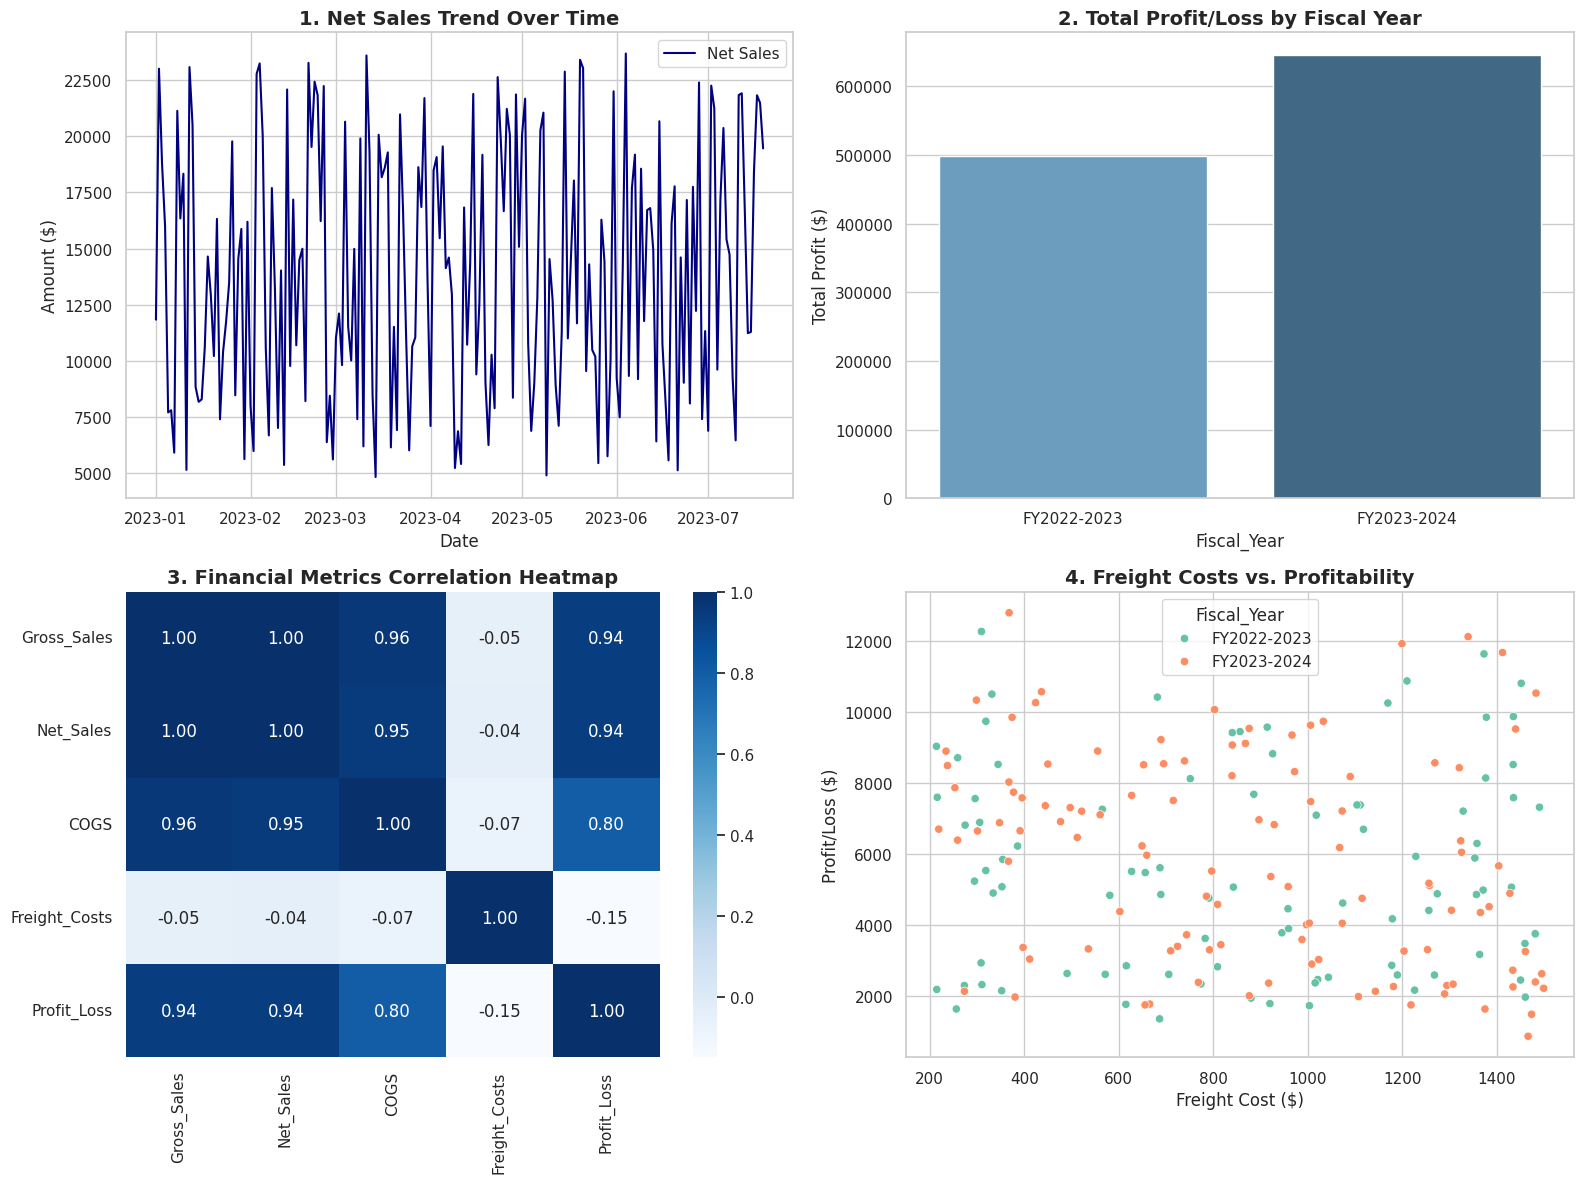


Task 3 Complete! All EDA steps, calculations, and visualizations rendered cleanly.


In [6]:
# ==============================================================================
# TASK 3 (ADVANCED LEVEL): OPTION 2 - EXPLORATORY DATA ANALYSIS (EDA)
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual styling for seaborn plots
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


print("1. GENERATING FINANCIAL & SALES DATASET")

np.random.seed(42)
n_records = 200

dates = pd.date_range(start="2023-01-01", periods=n_records, freq="D")
transaction_ids = [f"TXN-{1000 + i}" for i in range(n_records)]
gross_sales = np.random.uniform(5000, 25000, size=n_records)
cogs = gross_sales * np.random.uniform(0.4, 0.6, size=n_records)  # Cost of Goods Sold
freight_costs = np.random.uniform(200, 1500, size=n_records)
net_sales = gross_sales - (cogs * 0.1)  # Subtracting returns/discounts
profit_loss = net_sales - cogs - freight_costs

# Assign Fiscal Years
fiscal_years = []
for d in dates:
    if d.month >= 4:  # Fiscal year starts in April
        fiscal_years.append(f"FY{d.year}-{d.year+1}")
    else:
        fiscal_years.append(f"FY{d.year-1}-{d.year}")

# Build DataFrame
df = pd.DataFrame({
    "Transaction_ID": transaction_ids,
    "Date": dates,
    "Fiscal_Year": fiscal_years,
    "Gross_Sales": np.round(gross_sales, 2),
    "Net_Sales": np.round(net_sales, 2),
    "COGS": np.round(cogs, 2),
    "Freight_Costs": np.round(freight_costs, 2),
    "Profit_Loss": np.round(profit_loss, 2)
})

print("Dataset successfully loaded! First 5 records:")
print(df.head())
print("\n" + "=" * 70 + "\n")


print("2. DATASET EXPLORATION & CLEANING SUMMARY")
print("Dataset Shape:", df.shape)
print("\nMissing Values Check:\n", df.isnull().sum())
print("\nSummary Statistics:\n", df.describe().round(2))
print("\n" + "=" * 70 + "\n")


print("3. RESEARCH QUESTIONS & KEY FINDINGS")

# Research Question 1: Profitability by Fiscal Year
fy_summary = df.groupby("Fiscal_Year")[["Gross_Sales", "Net_Sales", "Profit_Loss"]].sum().round(2)
print("Q1: Total Sales and Profitability by Fiscal Year:")
print(fy_summary)
print()

# Research Question 2: Correlation between Freight/COGS and Profitability
corr = df[["Gross_Sales", "Net_Sales", "COGS", "Freight_Costs", "Profit_Loss"]].corr().round(2)
print("Q2: Financial Variables Correlation Matrix:")
print(corr)
print("\n" + "=" * 70 + "\n")


print("4. GENERATING VISUALIZATIONS")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Chart 1: Net Sales Trend over Time
sns.lineplot(data=df, x="Date", y="Net_Sales", ax=axes[0, 0], color="navy", label="Net Sales")
axes[0, 0].set_title("1. Net Sales Trend Over Time", fontsize=14, fontweight="bold")
axes[0, 0].set_ylabel("Amount ($)")

# Chart 2: Profit/Loss Distribution by Fiscal Year
sns.barplot(data=df, x="Fiscal_Year", y="Profit_Loss", hue="Fiscal_Year", ax=axes[0, 1], palette="Blues_d", estimator=sum, errorbar=None, legend=False)
axes[0, 1].set_title("2. Total Profit/Loss by Fiscal Year", fontsize=14, fontweight="bold")
axes[0, 1].set_ylabel("Total Profit ($)")

# Chart 3: Correlation Heatmap
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f", ax=axes[1, 0])
axes[1, 0].set_title("3. Financial Metrics Correlation Heatmap", fontsize=14, fontweight="bold")

# Chart 4: Impact of Freight Costs on Profit/Loss
sns.scatterplot(data=df, x="Freight_Costs", y="Profit_Loss", hue="Fiscal_Year", ax=axes[1, 1], palette="Set2")
axes[1, 1].set_title("4. Freight Costs vs. Profitability", fontsize=14, fontweight="bold")
axes[1, 1].set_xlabel("Freight Cost ($)")
axes[1, 1].set_ylabel("Profit/Loss ($)")

plt.tight_layout()
plt.show()

print("\nTask 3 Complete! All EDA steps, calculations, and visualizations rendered cleanly.")